# Trained Model Evaluation
This notebook evaluates a custom CNN trained to classify movie poster genres across different decades. 

In [1]:
import os
from pathlib import Path
os.chdir(Path().resolve().parent)

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from data_loader.data_loaders import label_encoding, get_dataloader, get_within_decade_split, get_transfer_split, transform
from models.cnn import PosterCNN

In [2]:
import yaml
with open("configs/default.yaml") as f:
    config = yaml.safe_load(f)

In [3]:
df = pd.read_csv(config["data"]["metadata_path"])

label_to_idx, idx_to_label = label_encoding(df)

num_classes = len(label_to_idx)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
print(f'Classes: {list(label_to_idx.keys())}')
print(f'Total samples: {len(df)}')

Classes: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']
Total samples: 85555


In [6]:
def load_and_evaluate(exp_name, test_df):
    model = PosterCNN(num_classes=num_classes)
    model.load_state_dict(torch.load(f'checkpoints/{exp_name}_best.pt', weights_only=True, map_location=device))

    model = model.to(device)
    model.eval()

    loader = get_dataloader(test_df, label_to_idx, transform, batch_size=64, shuffle=False, num_workers=0)

    all_predictions = []
    
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            predictions = model(images).argmax(dim=1).cpu()
            all_predictions.append(predictions)
            all_labels.append(labels)

    return torch.cat(all_predictions).numpy(), torch.cat(all_labels).numpy()

In [7]:
experiments = {
    "within_1980s": get_within_decade_split(df, 1980),
    "within_2010s": get_within_decade_split(df, 2010),
    "forward_1980s_1990s": get_transfer_split(df, 1980, 1990),
    "large_gap_1980s_2020s": get_transfer_split(df, 1980, 2020),
    "backward_2010s_1980s": get_transfer_split(df, 2010, 1980),
}

Within 1980s | Train: 15376 | Val: 1922 | Test: 1922
Within 2010s | Train: 14216 | Val: 1778 | Test: 1778
Transfer 1980s -> 1990s | Train: 15376 | Val: 3844 | Test: 22489
Transfer 1980s -> 2020s | Train: 15376 | Val: 3844 | Test: 4390
Transfer 2010s -> 1980s | Train: 14217 | Val: 3555 | Test: 19220


### Produce results using best model weights

In [8]:
results = {}

for exp_name, (train_df, val_df, test_df) in experiments.items():
    predictions, labels = load_and_evaluate(exp_name, test_df)
    f1 = f1_score(labels, predictions, average="macro")
    results[exp_name] = {'predictions': predictions, 'labels': labels, 'f1': f1}

    print(f'{exp_name}: F1 = {f1:.4f}')

within_1980s: F1 = 0.4744
within_2010s: F1 = 0.4406
forward_1980s_1990s: F1 = 0.0690
large_gap_1980s_2020s: F1 = 0.0734
backward_2010s_1980s: F1 = 0.0736


### Plot results figures

/tmp/ipykernel_3022219/1448773982.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=15, ha='right')


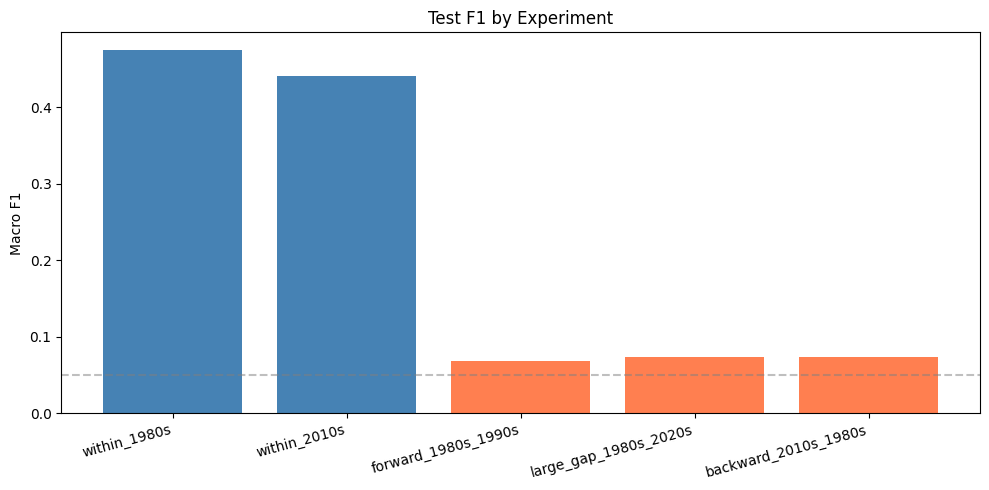

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
f1s = [results[e]['f1'] for e in names]
colors = ['steelblue', 'steelblue', 'coral', 'coral', 'coral']


ax.bar(names, f1s, color=colors)
ax.axhline(y=0.05, color='gray', linestyle='--', alpha=0.5, label='Near-random threshold')
ax.set_ylabel("Macro F1")
ax.set_title("Test F1 by Experiment")
ax.set_xticklabels(names, rotation=15, ha='right')
plt.tight_layout()
plt.savefig("assets/f1_summary.png", dpi=150)
plt.show()

The dashed line above represents the near-random threshold, which for a 19-class dataset is roughly ~0.05. As we can see, all three transfer experiments lie just barely above that line, indicating their performance is just slightly better than random chance. 

Within 2010s | Train: 14216 | Val: 1778 | Test: 1778


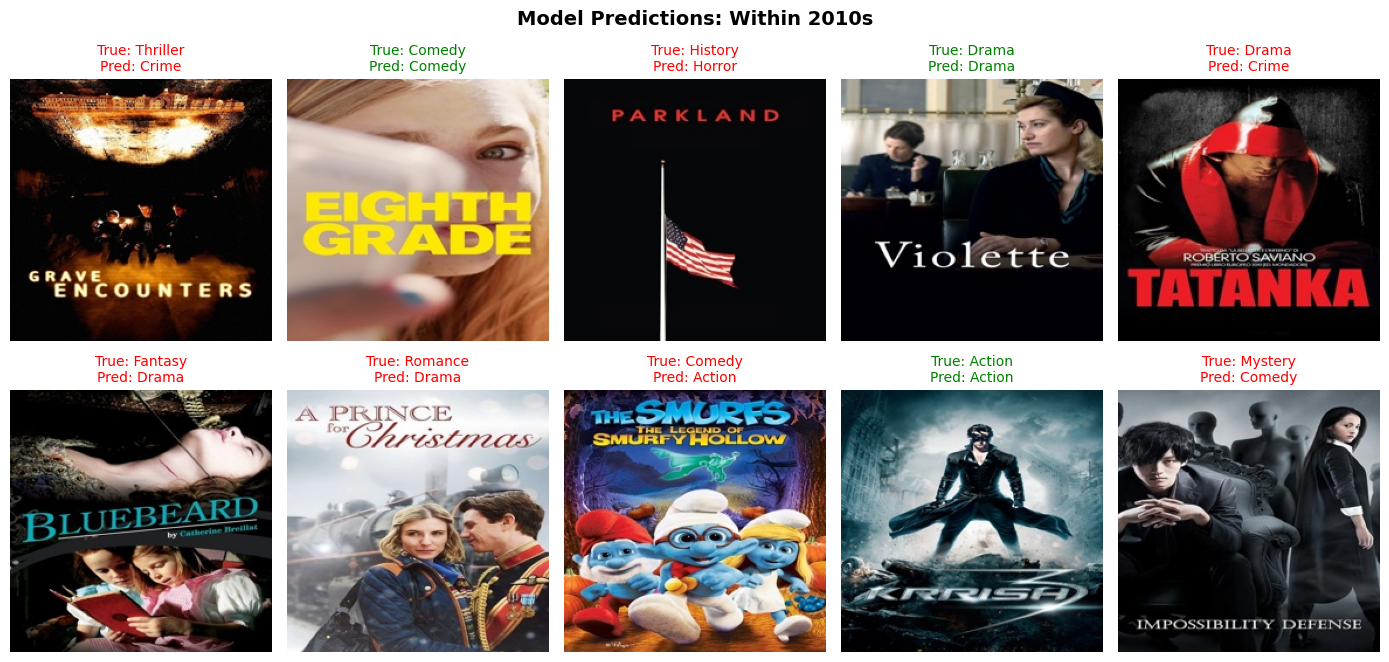

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(14, 7))
fig.suptitle("Model Predictions: Within 2010s", fontsize=14, fontweight='bold')

# get a batch from test set
_, _, test_df = get_within_decade_split(df, 2010)
sample = test_df.sample(10, random_state=42).reset_index(drop=True)

model = PosterCNN(num_classes=num_classes)
model.load_state_dict(torch.load("checkpoints/within_2010s_best.pt", weights_only=True, map_location=device))
model = model.to(device)
model.eval()

for i, (ax, (_, row)) in enumerate(zip(axes.flatten(), sample.iterrows())):
    img = Image.open(row["img_path"]).convert("RGB")
    
    # predict
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(tensor).argmax(dim=1).item()
    
    ax.imshow(img)
    true_label = row["primary_genre"]
    pred_label = idx_to_label[pred]
    correct = true_label == pred_label
    
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", 
                 color='green' if correct else 'red', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig("assets/sample_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

The plot above visually introduces a pitfall of the model - the dataset only associates one genre with each film. For example, the film Bluebeard (2010) is cross-listed as a "Fantasy/Drama" film, but only credited as "Fantasy" in the data, making the model's prediction of "Drama" incorrect. This choice was made to simplify the model, however we can see that this is a design flaw and hurts the model's predictions and accuracy in the long run. 

Transfer 1980s -> 2020s | Train: 15376 | Val: 3844 | Test: 4390


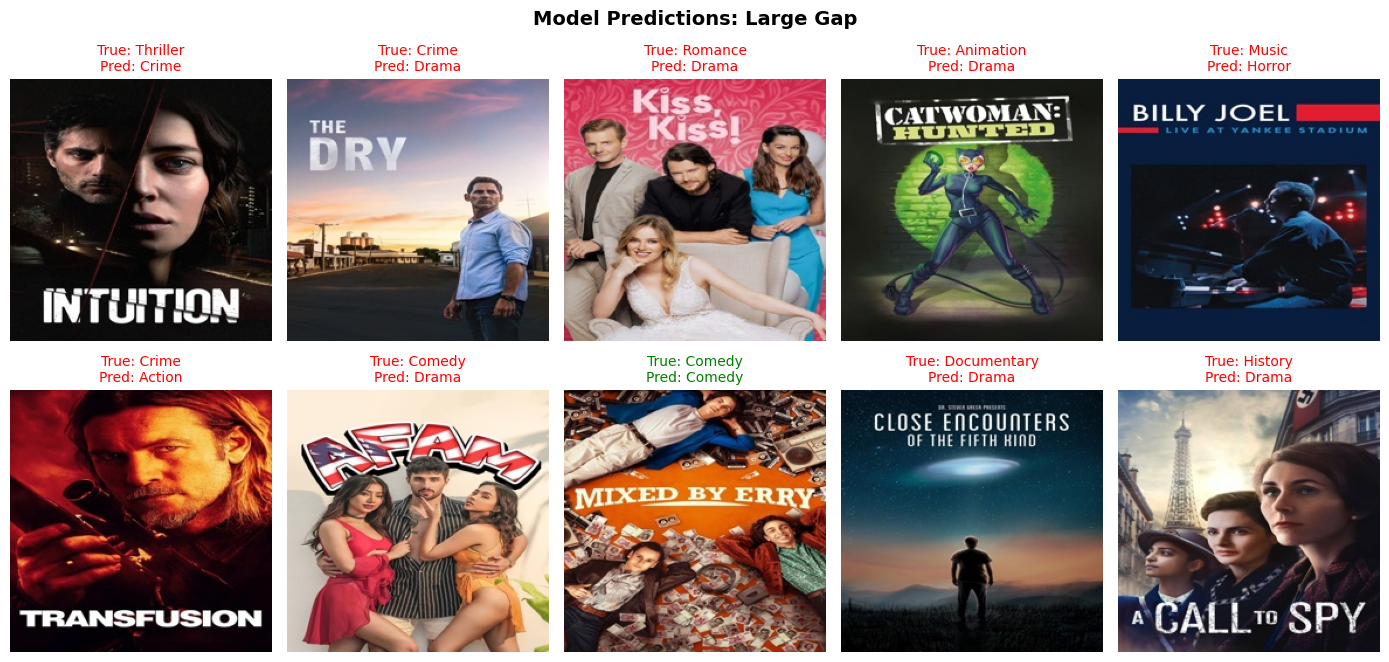

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(14, 7))
fig.suptitle("Model Predictions: Large Gap", fontsize=14, fontweight='bold')

# get a batch from test set
_, _, test_df = get_transfer_split(df, 1980, 2020)
sample = test_df.sample(10, random_state=42).reset_index(drop=True)

model = PosterCNN(num_classes=num_classes)
model.load_state_dict(torch.load("checkpoints/large_gap_1980s_2020s_best.pt", weights_only=True, map_location=device))
model = model.to(device)
model.eval()

for i, (ax, (_, row)) in enumerate(zip(axes.flatten(), sample.iterrows())):
    img = Image.open(row["img_path"]).convert("RGB")
    
    # predict
    tensor = transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        pred = model(tensor).argmax(dim=1).item()
    
    ax.imshow(img)
    true_label = row["primary_genre"]
    pred_label = idx_to_label[pred]
    correct = true_label == pred_label
    
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", 
                 color='green' if correct else 'red', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig("assets/sample_transfer_predictions.png", dpi=150, bbox_inches='tight')
plt.show()

Above's plots show a small subset of predictions from the large gap model (1980s --> 2020s). As we can see, the model fails on nearly every prediction.

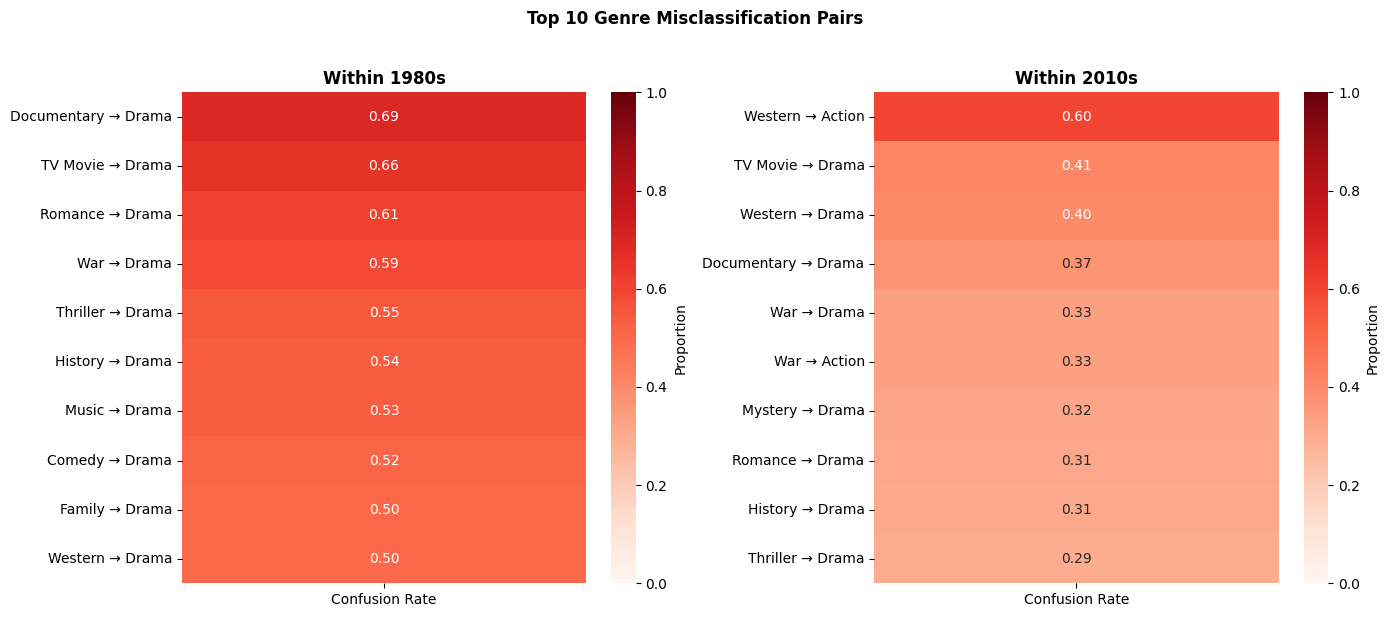

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
genre_names = np.array(list(label_to_idx.keys()))

for ax, exp_name, title in zip(axes,
                                ["within_1980s", "within_2010s"],
                                ["Within 1980s", "Within 2010s"]):
    cm = confusion_matrix(results[exp_name]["labels"], results[exp_name]["predictions"], normalize='true')
    np.fill_diagonal(cm, 0)
    
    # get top 10 confused pairs
    flat_idx = np.argsort(cm.flatten())[::-1][:10]
    rows, cols = np.unravel_index(flat_idx, cm.shape)
    
    pairs = [f"{genre_names[r]} → {genre_names[c]}" for r, c in zip(rows, cols)]
    values = [cm[r, c] for r, c in zip(rows, cols)]
    
    # plot as horizontal heatmap
    data = np.array(values).reshape(1, -1)
    sns.heatmap(pd.DataFrame(values, index=pairs, columns=["Confusion Rate"]),
                annot=True, fmt='.2f', ax=ax,
                cmap='Reds', vmin=0, vmax=1,
                cbar_kws={'label': 'Proportion'})
    ax.set_title(title, fontweight='bold')
    plt.setp(ax.get_yticklabels(), rotation=0)

plt.suptitle("Top 10 Genre Misclassification Pairs", fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("assets/top_confusion_pairs.png", dpi=150, bbox_inches='tight')
plt.show()

Within the 1980s decade, we can see that the model heavily favors the drama genre in its predictions, with nearly 10 genres consistently being confused for it. This could be a result of the class imbalance inherent in the data.

Drama is still over-predicted in the 2010s model, alongside action. The pattern is less pronounced than in the 1980s model, suggesting that the model is able to learn slighly more genre-specific features from 2010s films. However, the over-prediction of drama and action suggest that class imbalnce and genre overlap remain significant challenges.

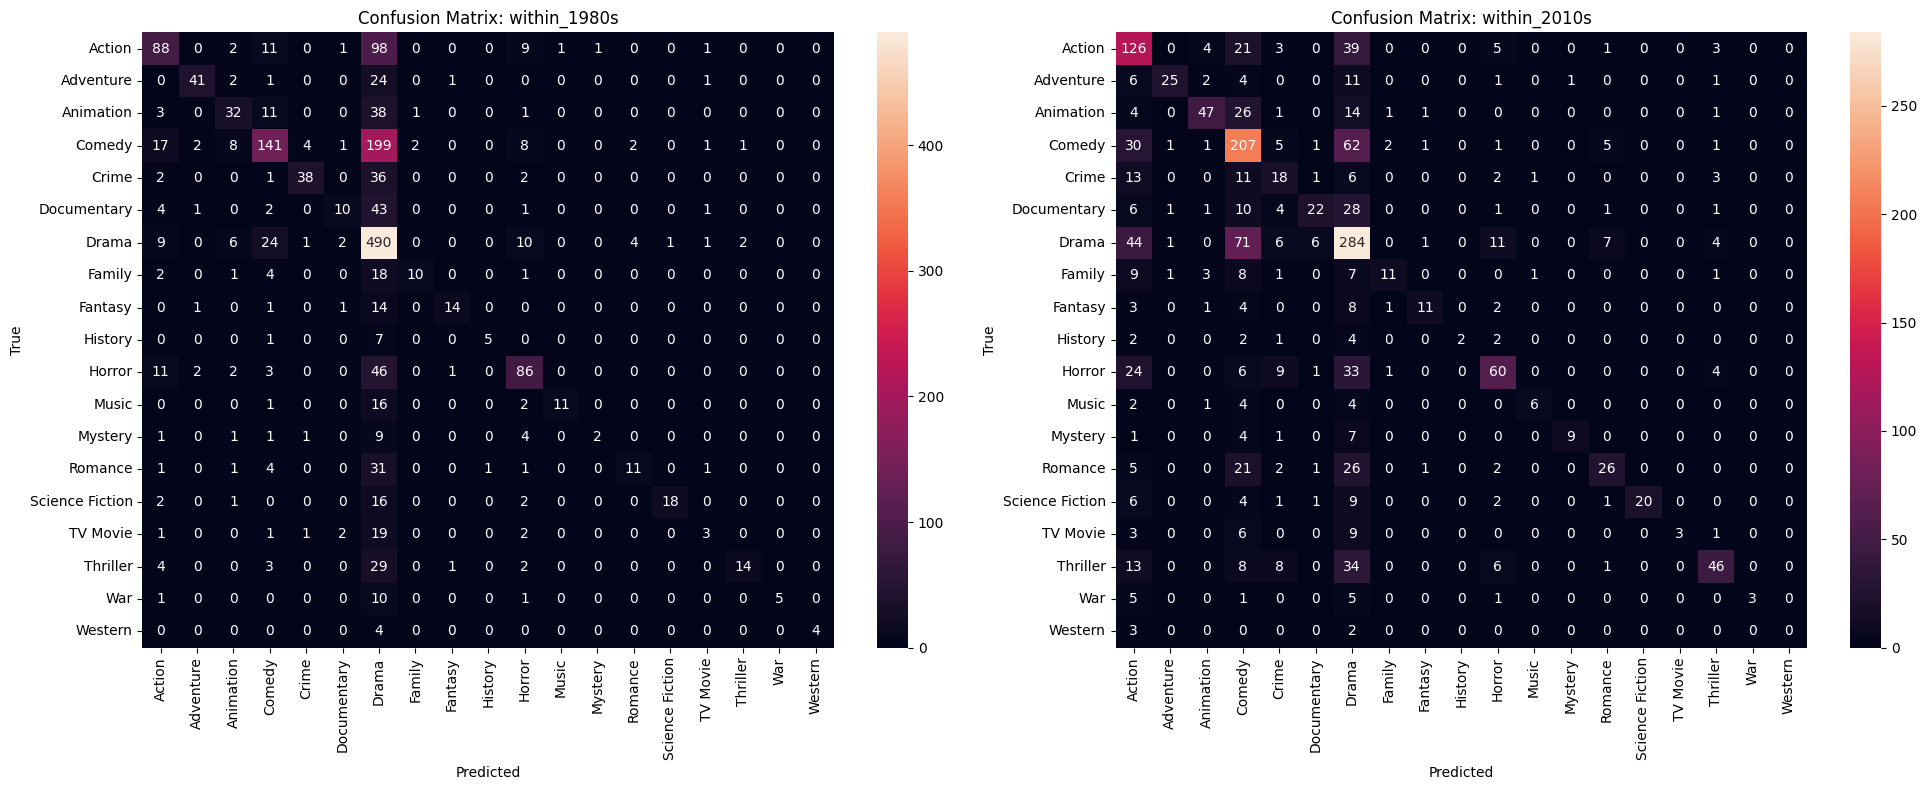

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
genre_names = list(label_to_idx.keys())

for ax, exp_name in zip(axes, ["within_1980s", "within_2010s"]):
    cm = confusion_matrix(results[exp_name]["labels"], results[exp_name]["predictions"])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=genre_names, yticklabels=genre_names)
    ax.set_title(f"Confusion Matrix: {exp_name}")
    ax.set_ylabel("True")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.savefig("assets/confusion_matrices.png", dpi=150)
plt.show()

This figure again shows common misclassification pairs for the 1980s and 2010s models. We can also see the large class imbalance - in the 1980s data there are over 500 drama films, while there are only eight westerns. 

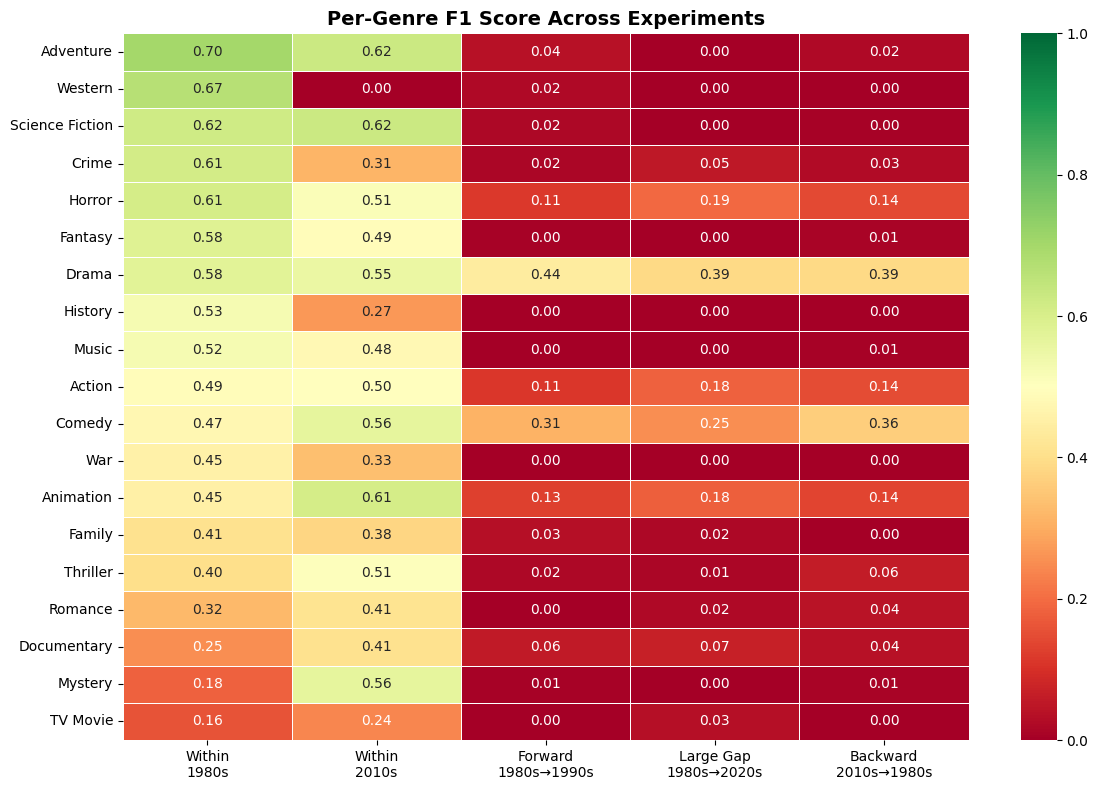

In [18]:
genre_names = list(label_to_idx.keys())

genre_f1s = {}
for exp_name, data in results.items():
    per_class = f1_score(data["labels"], data["predictions"], average=None, zero_division=0)
    genre_f1s[exp_name] = per_class

genre_f1_df = pd.DataFrame(genre_f1s, index=genre_names)

genre_f1_df.columns = [
    "Within\n1980s",
    "Within\n2010s", 
    "Forward\n1980s→1990s",
    "Large Gap\n1980s→2020s",
    "Backward\n2010s→1980s"
]

genre_f1_df = genre_f1_df.sort_values("Within\n1980s", ascending=False)

plt.figure(figsize=(12, 8))
sns.heatmap(
    genre_f1_df,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Per-Genre F1 Score Across Experiments", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("assets/per_genre_f1_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

Looking at the figure above, we can see that drama and comedy remain the most understood genres across all five models. Specifically comparing 1980s and 2010s F1 scores, we can see that there is a stark increase/decrease between the western, crime, history, and mystery genres. This could be a consequence of shifts in genre prevalance and representation over time, results in different amounts and types of training data being available for each decade. 